In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import files
uploaded = files.upload()

Saving disease_diagnosis.csv to disease_diagnosis.csv


In [4]:
health_df = pd.read_csv('disease_diagnosis.csv')

In [5]:
health_df.head()

,Patient_ID,Age,Gender,Symptom_1,Symptom_2,Symptom_3,Heart_Rate_bpm,Body_Temperature_C,Blood_Pressure_mmHg,Oxygen_Saturation_%,Diagnosis,Severity,Treatment_Plan
0,1,74,Male,Fatigue,Sore throat,Fever,69,39.4,132/91,94,Flu,Moderate,Medication and rest
1,2,66,Female,Sore throat,Fatigue,Cough,95,39.0,174/98,98,Healthy,Mild,Rest and fluids
2,3,32,Male,Body ache,Sore throat,Fatigue,77,36.8,136/60,96,Healthy,Mild,Rest and fluids
3,4,21,Female,Shortness of breath,Headache,Cough,72,38.9,147/82,99,Healthy,Mild,Rest and fluids
4,5,53,Male,Runny nose,Sore throat,Fatigue,100,36.6,109/106,92,Healthy,Mild,Rest and fluids


In [6]:
health_df.tail()

,Patient_ID,Age,Gender,Symptom_1,Symptom_2,Symptom_3,Heart_Rate_bpm,Body_Temperature_C,Blood_Pressure_mmHg,Oxygen_Saturation_%,Diagnosis,Severity,Treatment_Plan
1995,1996,23,Female,Sore throat,Runny nose,Shortness of breath,96,38.2,116/113,98,Healthy,Mild,Rest and fluids
1996,1997,75,Male,Fatigue,Cough,Sore throat,68,36.1,166/113,97,Cold,Mild,Rest and fluids
1997,1998,79,Male,Fatigue,Runny nose,Fever,73,36.7,91/103,95,Healthy,Mild,Rest and fluids
1998,1999,56,Female,Cough,Sore throat,Headache,67,39.1,128/73,91,Bronchitis,Severe,Hospitalization and medication
1999,2000,45,Female,Fatigue,Body ache,Fever,111,35.8,127/78,94,Healthy,Mild,Rest and fluids


In [7]:
health_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2000 non-null   int64  
 1   Age                  2000 non-null   int64  
 2   Gender               2000 non-null   object 
 3   Symptom_1            2000 non-null   object 
 4   Symptom_2            2000 non-null   object 
 5   Symptom_3            2000 non-null   object 
 6   Heart_Rate_bpm       2000 non-null   int64  
 7   Body_Temperature_C   2000 non-null   float64
 8   Blood_Pressure_mmHg  2000 non-null   object 
 9   Oxygen_Saturation_%  2000 non-null   int64  
 10  Diagnosis            2000 non-null   object 
 11  Severity             2000 non-null   object 
 12  Treatment_Plan       2000 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 203.3+ KB


In [9]:
health_df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3',
       'Heart_Rate_bpm', 'Body_Temperature_C', 'Blood_Pressure_mmHg',
       'Oxygen_Saturation_%', 'Diagnosis', 'Severity', 'Treatment_Plan'],
      dtype='object')

In [10]:
health_df.describe()

,Patient_ID,Age,Heart_Rate_bpm,Body_Temperature_C,Oxygen_Saturation_%
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,48.285000,89.439000,37.741000,94.493500
std,577.494589,17.422616,17.139608,1.309835,2.861827
min,1.000000,18.000000,60.000000,35.500000,90.000000
25%,500.750000,33.000000,75.000000,36.600000,92.000000
50%,1000.500000,49.000000,89.000000,37.700000,95.000000
75%,1500.250000,63.000000,104.000000,38.900000,97.000000
max,2000.000000,79.000000,119.000000,40.000000,99.000000


In [11]:
health_df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Symptom_1,0
Symptom_2,0
Symptom_3,0
Heart_Rate_bpm,0
Body_Temperature_C,0
Blood_Pressure_mmHg,0
Oxygen_Saturation_%,0


In [12]:
numerical_cols = health_df.select_dtypes(include=['int64', 'float64']).columns

num_imputer = SimpleImputer(strategy = 'mean')


health_df[numerical_cols] = num_imputer.fit_transform(
    health_df[numerical_cols]
)

In [14]:
categorical_cols = health_df.select_dtypes(include = ['object']).columns

col_imputer = SimpleImputer(strategy = 'most_frequent')

health_df[categorical_cols] = col_imputer.fit_transform(
    health_df[categorical_cols]
)

In [15]:
label_encoder = {}

for col in categorical_cols:
  le = LabelEncoder()
  health_df[col] = le.fit_transform(health_df[col])
  label_encoder[col] = le

In [17]:
target_column = 'Diagnosis'

X = health_df.drop(columns = [target_column], axis=1)
y = health_df[target_column]

print(X.head())
print(y.head())

   Patient_ID   Age  Gender  Symptom_1  Symptom_2  Symptom_3  Heart_Rate_bpm  \
0         1.0  74.0       1          2          7          3            69.0   
1         2.0  66.0       0          7          2          1            95.0   
2         3.0  32.0       1          0          7          2            77.0   
3         4.0  21.0       0          6          4          1            72.0   
4         5.0  53.0       1          5          7          2           100.0   

   Body_Temperature_C  Blood_Pressure_mmHg  Oxygen_Saturation_%  Severity  \
0                39.4                  613                 94.0         1   
1                39.0                 1410                 98.0         0   
2                36.8                  664                 96.0         0   
3                38.9                  883                 99.0         0   
4                36.6                  156                 92.0         0   

   Treatment_Plan  
0               1  
1               

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaed = pd.DataFrame(X_scaled, columns = X.columns)



In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y , test_size = 0.2, random_state = 42, stratify = y)


print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

Shape of X_train: (1600, 12)
Shape of X_test: (400, 12)


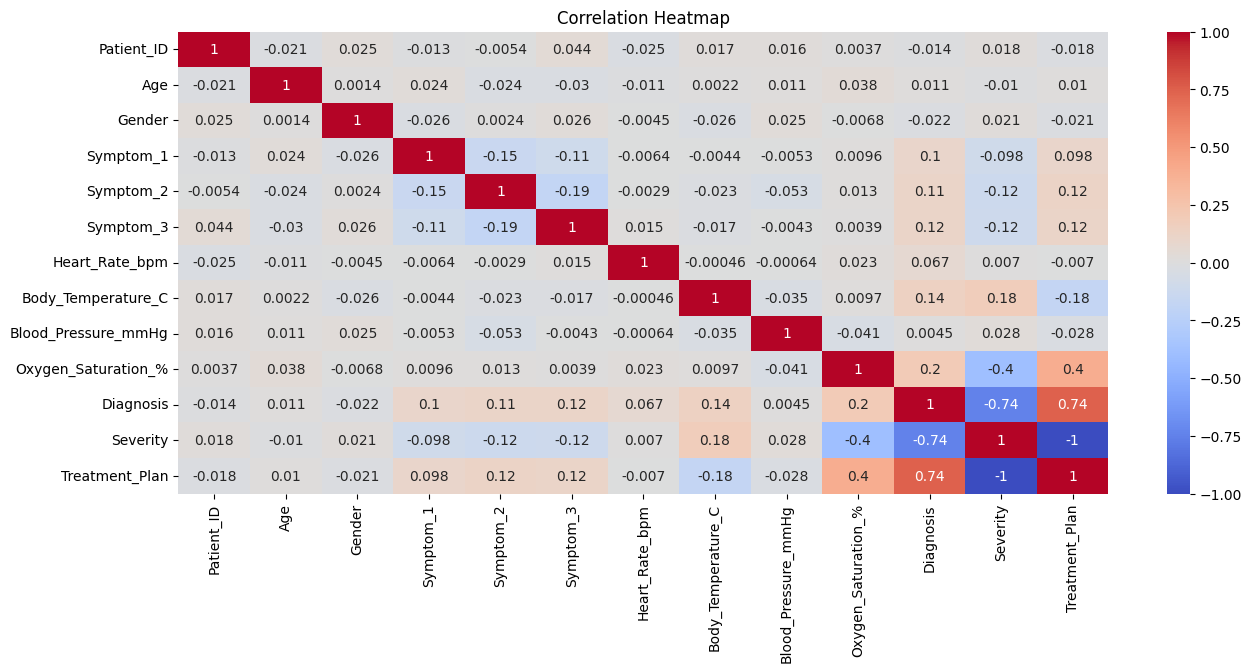

In [21]:
plt.figure(figsize = (15,6))

sns.heatmap(health_df.corr(), annot = True, cmap = 'coolwarm')

plt.title('Correlation Heatmap')

plt.show()

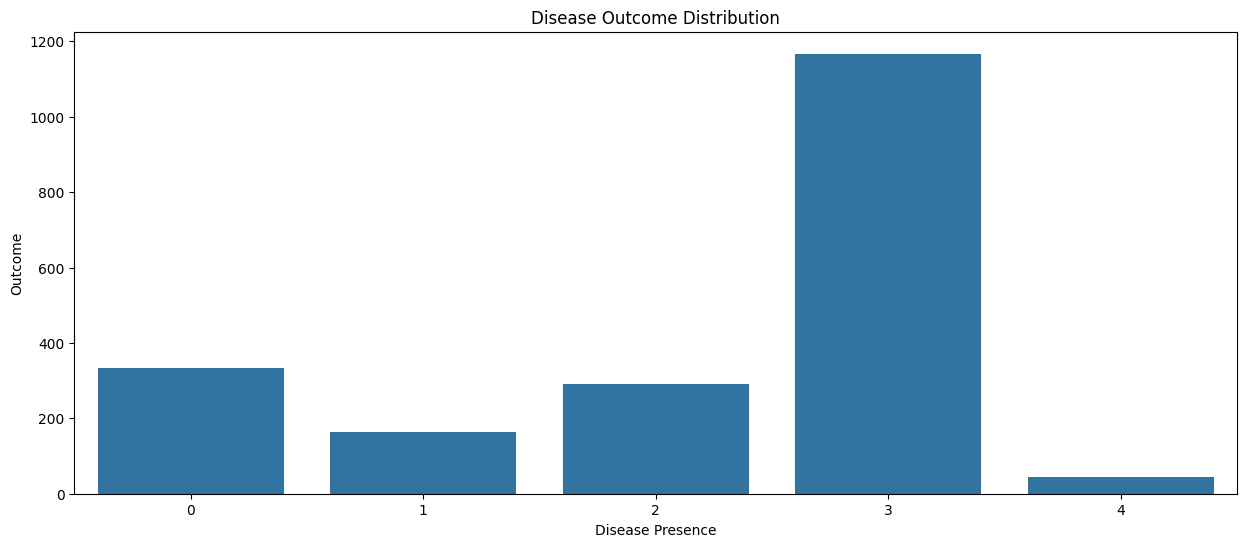

In [22]:
plt.figure(figsize = (15,6))

sns.countplot(x=y)

plt.title('Disease Outcome Distribution')
plt.xlabel('Disease Presence')
plt.ylabel('Outcome')

plt.show()

In [23]:
diagnosis_decoder = label_encoder['Diagnosis']
decoded_value = diagnosis_decoder.inverse_transform([3])
print(f"The value '3' in the Diagnosis column represents: {decoded_value[0]}")

The value '3' in the Diagnosis column represents: Healthy


In [26]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print('===== Logistic Regression =====')
print('Accuracy:', accuracy_score(y_test, log_pred))
print('Precision:', precision_score(y_test, log_pred, average='weighted'))
print('Recall:', recall_score(y_test, log_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, log_pred, average='weighted'))

print(classification_report(y_test, log_pred))

===== Logistic Regression =====
Accuracy: 0.9575
Precision: 0.9552851077050538
Recall: 0.9575
F1 Score: 0.9545934510108869
              precision    recall  f1-score   support

           0       0.93      0.99      0.96        67
           1       0.89      0.76      0.82        33
           2       1.00      1.00      1.00        58
           3       0.97      0.99      0.98       233
           4       0.80      0.44      0.57         9

    accuracy                           0.96       400
   macro avg       0.92      0.83      0.86       400
weighted avg       0.96      0.96      0.95       400



In [28]:
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


print('===== Random Forest =====')
print('Accuracy:', accuracy_score(y_test, rf_pred))
print('Precision:', precision_score(y_test, rf_pred, average='weighted'))
print('Recall:', recall_score(y_test, rf_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, rf_pred, average='weighted'))

print(classification_report(y_test, rf_pred))

===== Random Forest =====
Accuracy: 0.99
Precision: 0.9905633802816902
Recall: 0.99
F1 Score: 0.9887163561076605
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        67
           1       1.00      1.00      1.00        33
           2       1.00      1.00      1.00        58
           3       1.00      1.00      1.00       233
           4       1.00      0.56      0.71         9

    accuracy                           0.99       400
   macro avg       0.99      0.91      0.94       400
weighted avg       0.99      0.99      0.99       400



In [30]:
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)


print('===== XGBoost =====')
print('Accuracy:', accuracy_score(y_test, xgb_pred))
print('Precision:', precision_score(y_test, xgb_pred, average='weighted'))
print('Recall:', recall_score(y_test, xgb_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, xgb_pred, average='weighted'))

===== XGBoost =====
Accuracy: 0.995
Precision: 0.9951449275362318
Recall: 0.995
F1 Score: 0.9947242647058823


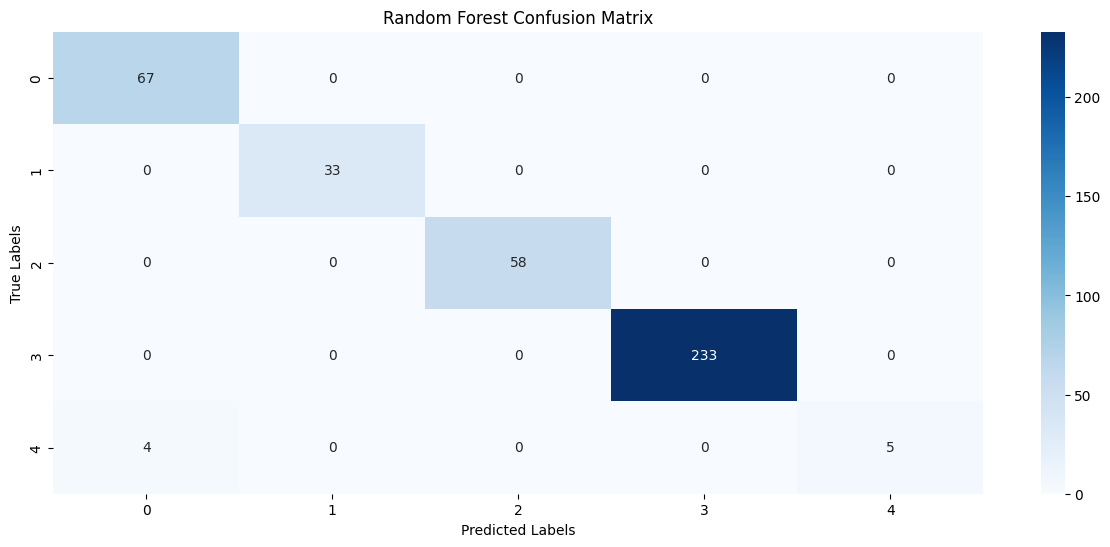

In [31]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize = (15,6))

sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.show()

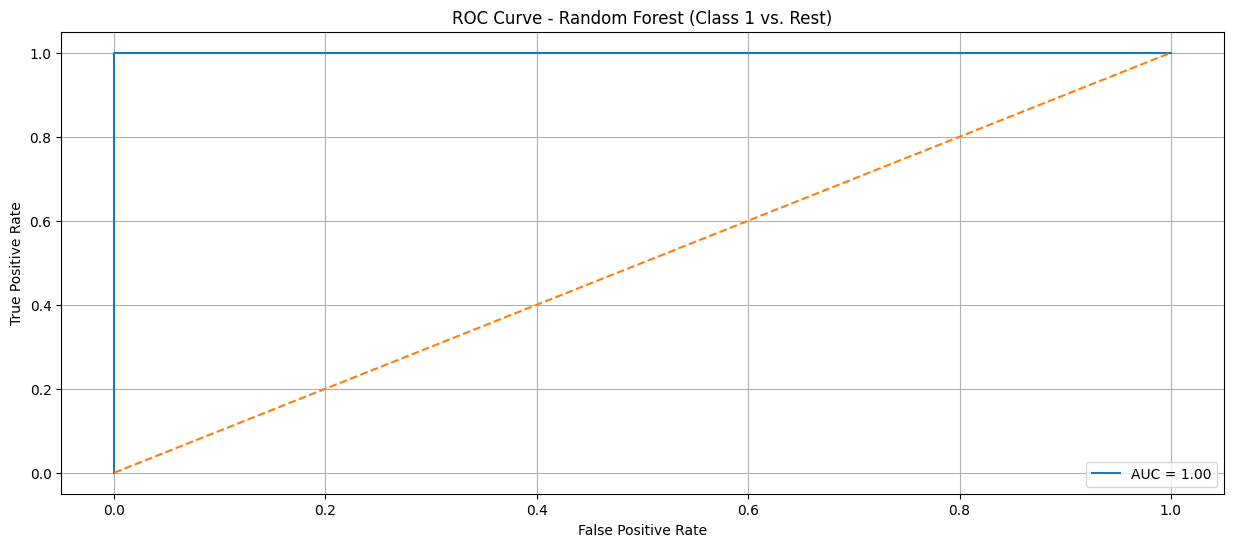

In [33]:
rf_probs = rf_model.predict_proba(X_test)[:,1]

# Binarize y_test for the specific class whose probabilities are in rf_probs (class 1)
y_test_binary_for_class_1 = (y_test == 1).astype(int)

fpr, tpr, threholds = roc_curve(y_test_binary_for_class_1, rf_probs)
roc_auc = roc_auc_score(y_test_binary_for_class_1, rf_probs)

plt.figure(figsize=(15,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.title('ROC Curve - Random Forest (Class 1 vs. Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_

})



importance_df = importance_df.sort_values(by = 'Importance', ascending = False)

print(importance_df)



                Feature  Importance
10             Severity    0.305979
11       Treatment_Plan    0.304953
7    Body_Temperature_C    0.160762
9   Oxygen_Saturation_%    0.110047
6        Heart_Rate_bpm    0.020455
4             Symptom_2    0.019823
5             Symptom_3    0.018782
3             Symptom_1    0.017558
8   Blood_Pressure_mmHg    0.014371
0            Patient_ID    0.014324
1                   Age    0.010938
2                Gender    0.002009


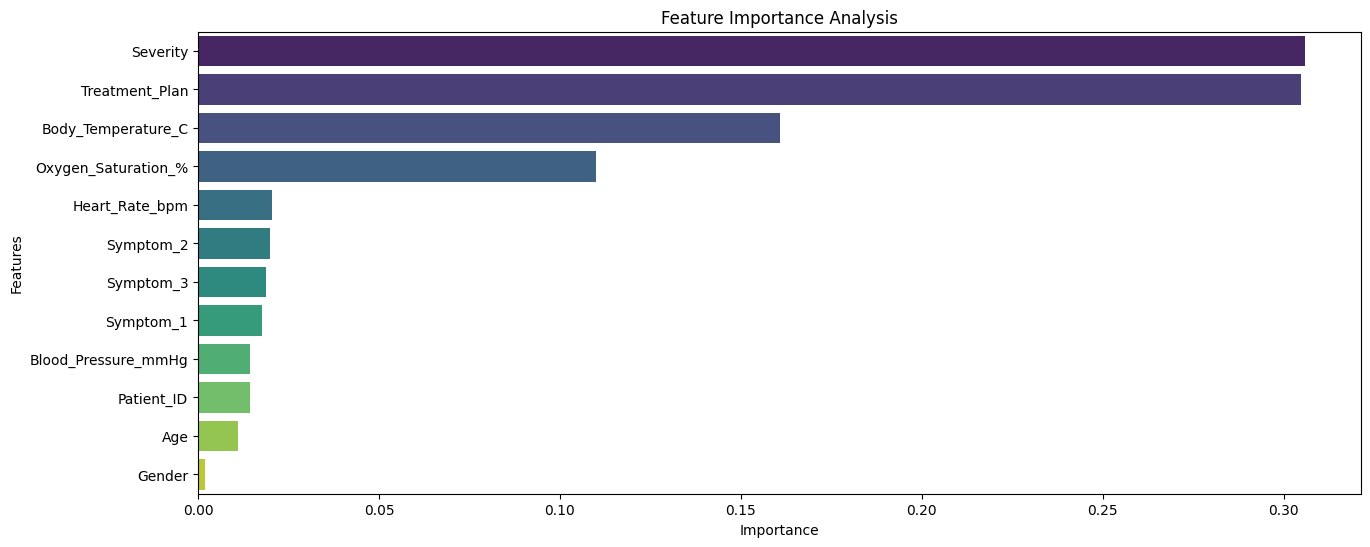

In [37]:
plt.figure(figsize = (15,6))

sns.barplot(x = 'Importance', y = 'Feature', data = importance_df, palette = 'viridis')

plt.title('Feature Importance Analysis')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [38]:
sample_patient = np.array([X.iloc[0].values])

sample_scaled = scaler.transform(sample_patient)

prediction = rf_model.predict(sample_scaled)
probability = rf_model.predict_proba(sample_scaled)

print('Predicted Disease Risk:', prediction[0])
print('Probability:', probability)

Predicted Disease Risk: 2
Probability: [[0.02 0.   0.98 0.   0.  ]]


In [40]:
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'F1 Score': [
        f1_score(y_test, log_pred, average='weighted'),
        f1_score(y_test, rf_pred, average='weighted'),
        f1_score(y_test, xgb_pred, average='weighted')
    ]
})

print(model_results)

                 Model  Accuracy  F1 Score
0  Logistic Regression    0.9575  0.954593
1        Random Forest    0.9900  0.988716
2              XGBoost    0.9950  0.994724


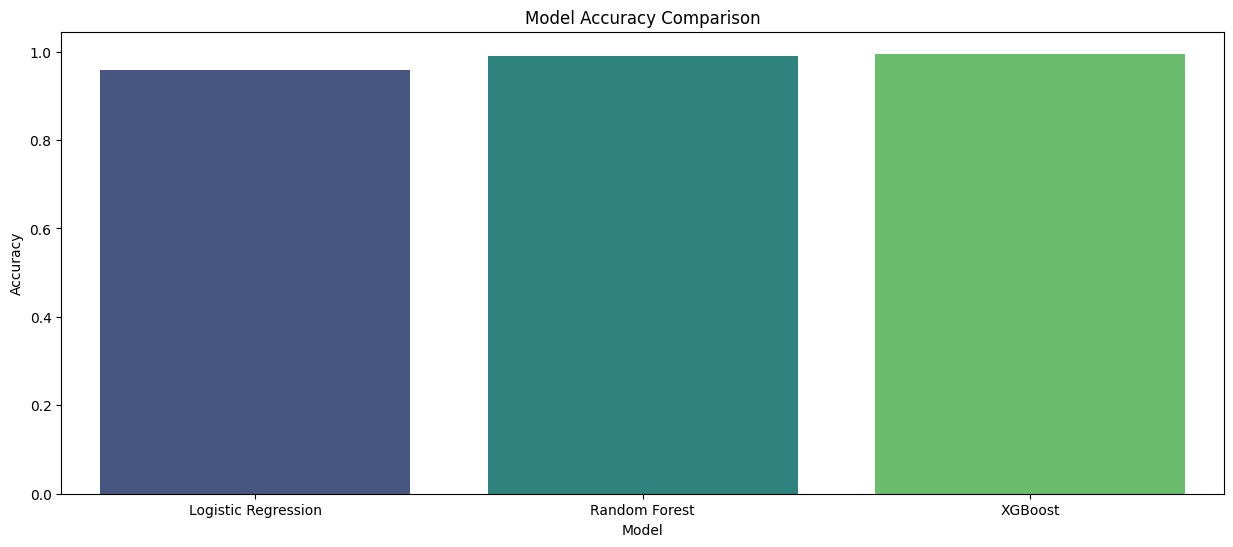

In [41]:
plt.figure(figsize = (15,6))

sns.barplot(x = 'Model', y = 'Accuracy', data = model_results, palette = 'viridis')

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.show()